# Práctica 02. Exploración y preprocesamiento del Breast Cancer Wisconsin (Original)

**Autor:** Aldo Santiago Márquez  
**Materia:** Introducción a la Ciencia de Datos

Primero reviso cómo vienen los datos. Después pruebo tres formas de prepararlos: completar los faltantes, crear una variable a partir de otras dos y reducir las nueve mediciones con PCA. Comparo el antes y el después con gráficas para entender qué cambió. En esta práctica no entreno un clasificador.

Trabajo con `breast-cancer-wisconsin.data` y la descripción `breast-cancer-wisconsin.names` que me dieron para la actividad.


## 1. Carga

El archivo no trae encabezados. Tomo los nombres de la descripción del conjunto y leo `?` como valor faltante. Si lo abro en Colab y el archivo no está cargado, la primera celda me pedirá subirlo.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", palette="Set2")
columnas = ["id", "grosor_grumos", "uniformidad_tamano", "uniformidad_forma",
            "adhesion_marginal", "tamano_epitelial", "nucleos_desnudos",
            "cromatina_blanda", "nucleolos_normales", "mitosis", "clase"]
variables = columnas[1:-1]
rutas = [Path("breast-cancer-wisconsin.data"),
         Path("Practicas/breast-cancer-wisconsin.data"),
         Path("upload/breast-cancer-wisconsin.data"),
         Path("/content/breast-cancer-wisconsin.data")]
ruta = next((p for p in rutas if p.is_file()), None)
if ruta is None:
    try:
        from google.colab import files
        print("Sube breast-cancer-wisconsin.data")
        subidos = files.upload()
        ruta = Path("breast-cancer-wisconsin.data")
        if ruta.name not in subidos:
            raise FileNotFoundError("Se necesita breast-cancer-wisconsin.data")
    except ImportError as exc:
        raise FileNotFoundError("Coloca breast-cancer-wisconsin.data junto al notebook.") from exc
df = pd.read_csv(ruta, header=None, names=columnas, na_values="?")
df[variables] = df[variables].apply(pd.to_numeric, errors="coerce")
df["diagnostico"] = df["clase"].map({2: "Benigno", 4: "Maligno"})
print("Tamaño:", len(df), "filas y", len(variables), "mediciones")
print(df.head().to_string(index=False))


Tamaño: 699 filas y 9 mediciones
     id  grosor_grumos  uniformidad_tamano  uniformidad_forma  adhesion_marginal  tamano_epitelial  nucleos_desnudos  cromatina_blanda  nucleolos_normales  mitosis  clase diagnostico
1000025              5                   1                  1                  1                 2               1.0                 3                   1        1      2     Benigno
1002945              5                   4                  4                  5                 7              10.0                 3                   2        1      2     Benigno
1015425              3                   1                  1                  1                 2               2.0                 3                   1        1      2     Benigno
1016277              6                   8                  8                  1                 3               4.0                 3                   7        1      2     Benigno
1017023              4                   1          

## 2. Análisis exploratorio

Reviso tipos, faltantes y filas repetidas. Algunos identificadores aparecen varias veces; no borro esos registros automáticamente, pues un ID repetido no demuestra que la observación sea un error.


In [2]:
print("Tipos de datos:")
print(df[columnas].dtypes.to_string())
print("\nValores faltantes:")
print(df[columnas].isna().sum().to_string())
print("\nFilas idénticas:", df[columnas].duplicated().sum())
print("IDs repetidos:", df["id"].duplicated().sum())
print("\nResumen de mediciones:")
print(df[variables].describe().round(2).to_string())


Tipos de datos:
id                      int64
grosor_grumos           int64
uniformidad_tamano      int64
uniformidad_forma       int64
adhesion_marginal       int64
tamano_epitelial        int64
nucleos_desnudos      float64
cromatina_blanda        int64
nucleolos_normales      int64
mitosis                 int64
clase                   int64

Valores faltantes:
id                     0
grosor_grumos          0
uniformidad_tamano     0
uniformidad_forma      0
adhesion_marginal      0
tamano_epitelial       0
nucleos_desnudos      16
cromatina_blanda       0
nucleolos_normales     0
mitosis                0
clase                  0

Filas idénticas: 8
IDs repetidos: 54

Resumen de mediciones:
       grosor_grumos  uniformidad_tamano  uniformidad_forma  adhesion_marginal  tamano_epitelial  nucleos_desnudos  cromatina_blanda  nucleolos_normales  mitosis
count         699.00              699.00             699.00             699.00            699.00            683.00            699.00   

La descripción del conjunto indica que las nueve mediciones van de 1 a 10. La clase 2 representa benigno y la 4, maligno. Compruebo rangos y distribución de las clases.


Valores fuera de 1–10: 0
diagnostico
Benigno    458
Maligno    241


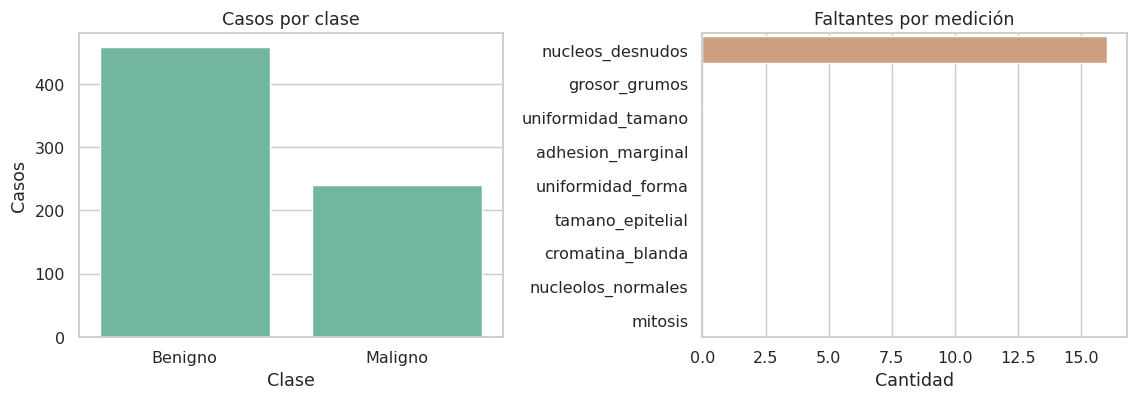

In [3]:
fuera = (~df[variables].isna() & ~(df[variables].ge(1) & df[variables].le(10))).sum().sum()
print("Valores fuera de 1–10:", int(fuera))
print(df["diagnostico"].value_counts().to_string())
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x="diagnostico", order=["Benigno","Maligno"], ax=ax[0])
ax[0].set(title="Casos por clase", xlabel="Clase", ylabel="Casos")
faltantes = df[variables].isna().sum().sort_values(ascending=False)
sns.barplot(x=faltantes.values, y=faltantes.index, ax=ax[1], color="#d99c73")
ax[1].set(title="Faltantes por medición", xlabel="Cantidad", ylabel="")
plt.tight_layout()
plt.show()


Hay más casos benignos. Los faltantes se concentran en núcleos desnudos. También quiero ver cómo se distribuye una medición y qué variables se relacionan entre sí antes de procesarlas.


Correlación tamaño–forma: 0.907


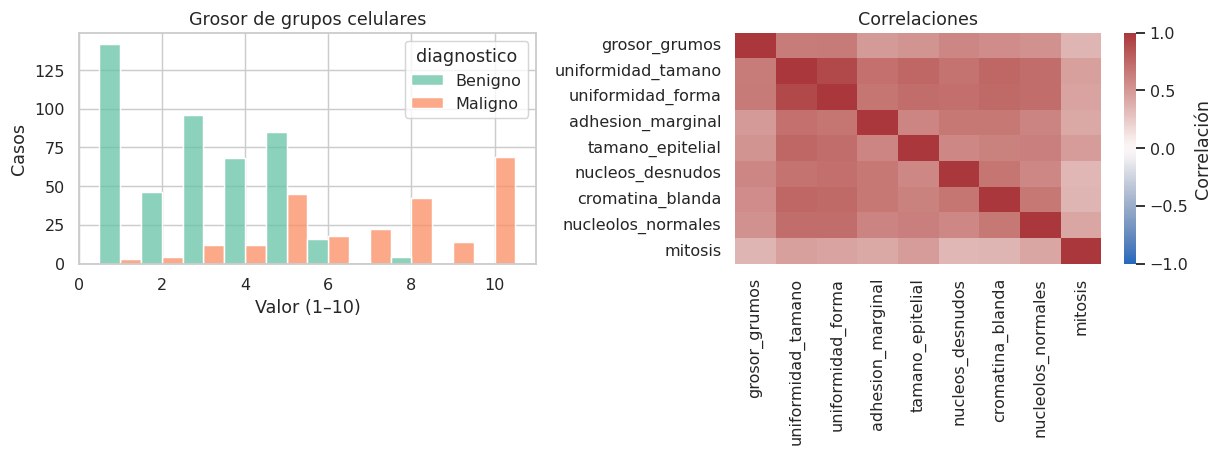

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(data=df, x="grosor_grumos", hue="diagnostico",
             hue_order=["Benigno","Maligno"], bins=np.arange(.5, 11.5, 1),
             multiple="dodge", ax=ax[0])
ax[0].set(title="Grosor de grupos celulares", xlabel="Valor (1–10)", ylabel="Casos")
sns.heatmap(df[variables].corr(), cmap="vlag", vmin=-1, vmax=1,
            center=0, ax=ax[1], cbar_kws={"label":"Correlación"})
ax[1].set(title="Correlaciones")
plt.tight_layout()
plt.show()
print("Correlación tamaño–forma:",
      round(df["uniformidad_tamano"].corr(df["uniformidad_forma"]), 3))


## 3. Técnica 1: completar valores faltantes

Encontré 16 faltantes en `nucleos_desnudos`. Uso la mediana de los valores disponibles para conservar las 699 filas. No conozco el valor real de esas 16 mediciones, así que después comparo cómo queda la distribución.


Mediana: 1.0
Faltantes antes: 16 | después: 0


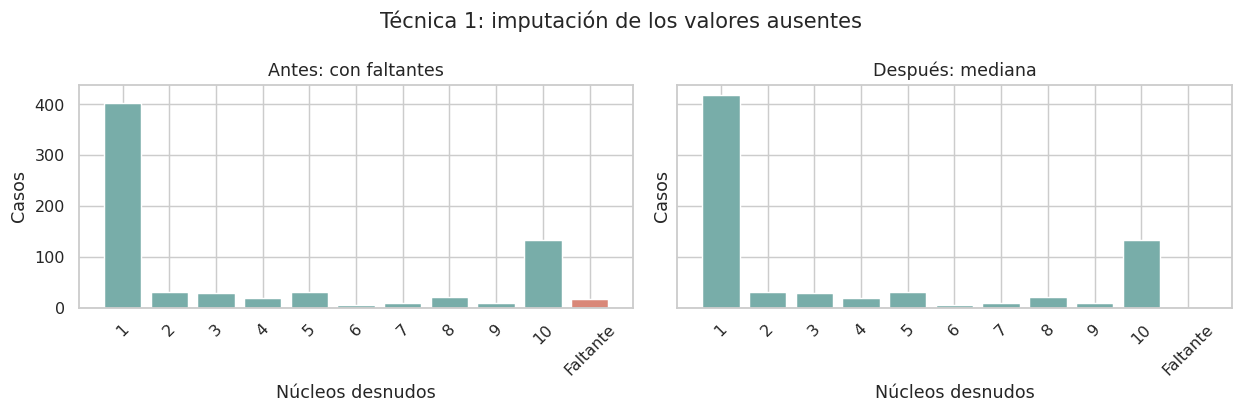

In [5]:
df_limpio = df.copy()
mediana = df_limpio["nucleos_desnudos"].median()
df_limpio["nucleos_desnudos"] = df_limpio["nucleos_desnudos"].fillna(mediana)
print("Mediana:", mediana)
print("Faltantes antes:", df[variables].isna().sum().sum(),
      "| después:", df_limpio[variables].isna().sum().sum())
antes = df["nucleos_desnudos"].value_counts().reindex(range(1,11), fill_value=0).tolist()
antes += [int(df["nucleos_desnudos"].isna().sum())]
despues = df_limpio["nucleos_desnudos"].value_counts().reindex(range(1,11), fill_value=0).tolist() + [0]
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for eje, counts, titulo in zip(ax, [antes, despues], ["Antes: con faltantes","Después: mediana"]):
    eje.bar([str(v) for v in list(range(1,11))+["Faltante"]], counts,
            color=["#78ada9"]*10+["#d98778"])
    eje.set(title=titulo, xlabel="Núcleos desnudos", ylabel="Casos")
    eje.tick_params(axis="x", labelrotation=45)
plt.suptitle("Técnica 1: imputación de los valores ausentes")
plt.tight_layout()
plt.show()


**Observación.** Los faltantes pasan a la categoría 1, porque esa fue la mediana. Así conservo las filas, pero también aumento la frecuencia de ese valor; la imputación no recupera las mediciones originales.


## 4. Técnica 2: crear una característica

La uniformidad del tamaño y la de la forma están bastante relacionadas en estos datos. Para probar una variable nueva, calculo el promedio de las dos y lo llamo `uniformidad_media`. Conservo también las columnas originales. Este promedio es solo una forma de resumirlas en la práctica, no una medida clínica.


 uniformidad_tamano  uniformidad_forma  uniformidad_media
                  1                  1                1.0
                  4                  4                4.0
                  1                  1                1.0
                  8                  8                8.0
                  1                  1                1.0


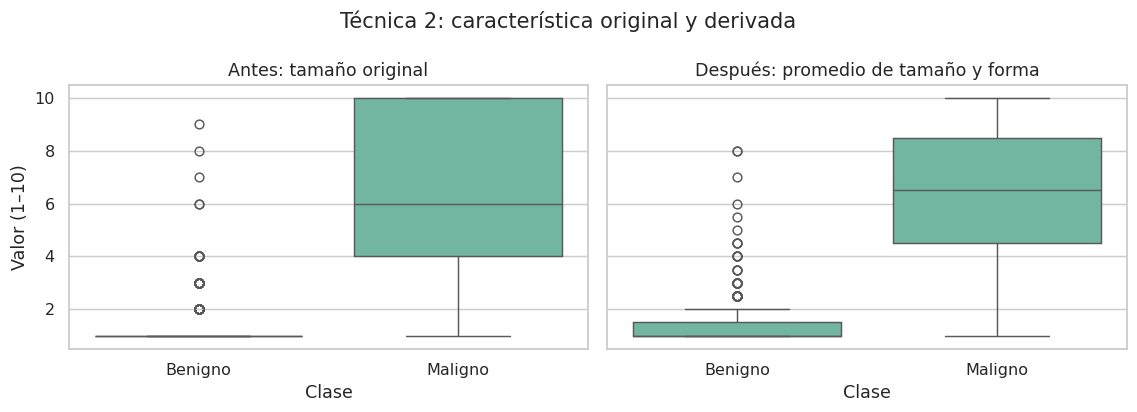

In [6]:
df_extraido = df_limpio.copy()
df_extraido["uniformidad_media"] = (
    df_extraido["uniformidad_tamano"] + df_extraido["uniformidad_forma"]
) / 2
print(df_extraido[["uniformidad_tamano","uniformidad_forma","uniformidad_media"]].head().to_string(index=False))
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for eje, col, titulo in zip(
    ax, ["uniformidad_tamano","uniformidad_media"],
    ["Antes: tamaño original","Después: promedio de tamaño y forma"]
):
    sns.boxplot(data=df_extraido, x="diagnostico", y=col,
                order=["Benigno","Maligno"], ax=eje)
    eje.set(title=titulo, xlabel="Clase", ylabel="Valor (1–10)", ylim=(.5,10.5))
plt.suptitle("Técnica 2: característica original y derivada")
plt.tight_layout()
plt.show()


**Observación.** La nueva columna incorpora la forma y puede tomar valores intermedios como 2.5. La gráfica muestra cómo cambia la distribución por clase. Agregar una variable no garantiza que un futuro modelo mejore.


## 5. Técnica 3: reducir dimensiones con PCA

Quiero ver cuánto de las nueve mediciones puedo representar con dos componentes. Primero estandarizo las columnas para que PCA trabaje con ellas en la misma escala. No uso el ID ni la clase. Tampoco incluyo `uniformidad_media`, porque repite información de dos columnas que ya están en el análisis. La clase solo aparece como color en la gráfica.


Dimensiones antes: (699, 9) | después: (699, 2)
Varianza explicada por cada componente: [65.4  8.6] %
Varianza explicada total: 74.1 %


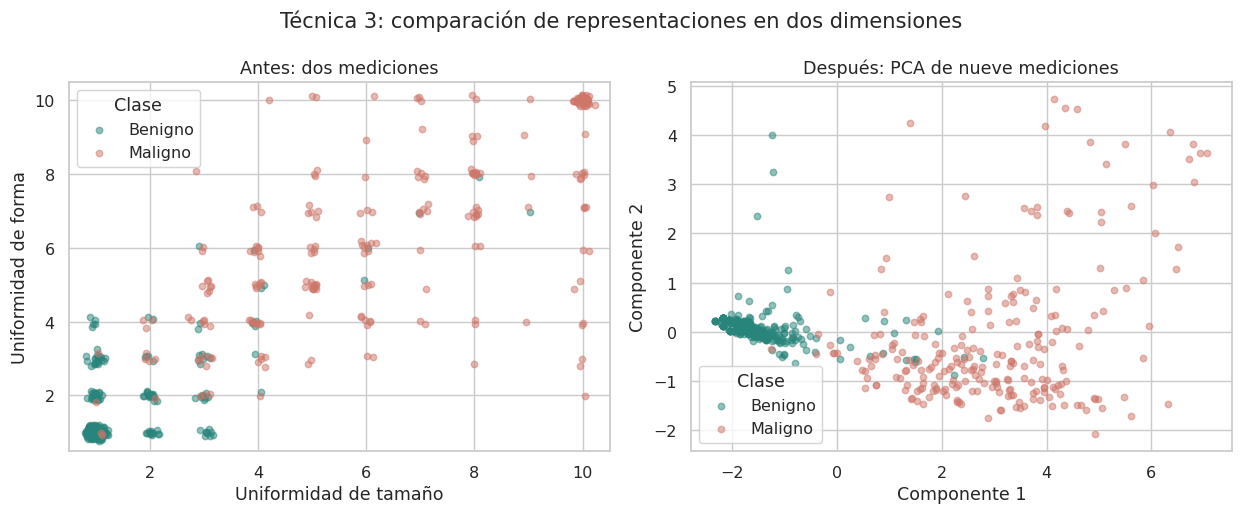

In [7]:
X = df_limpio[variables]
X_escalado = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
coordenadas = pca.fit_transform(X_escalado)
df_pca = pd.DataFrame(coordenadas, columns=["CP1","CP2"], index=df_limpio.index)
df_pca["diagnostico"] = df_limpio["diagnostico"]
print("Dimensiones antes:", X.shape, "| después:", coordenadas.shape)
print("Varianza explicada por cada componente:",
      np.round(pca.explained_variance_ratio_*100, 1), "%")
print("Varianza explicada total:",
      round(100*pca.explained_variance_ratio_.sum(), 1), "%")
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
colores = {"Benigno":"#28857b", "Maligno":"#cf7669"}
rng = np.random.default_rng(42)
for clase in ["Benigno","Maligno"]:
    mascara = df_limpio["diagnostico"].eq(clase)
    # Separación visual mínima de puntos enteros superpuestos.
    xj = df_limpio.loc[mascara,"uniformidad_tamano"].to_numpy() + rng.normal(0,.08,mascara.sum())
    yj = df_limpio.loc[mascara,"uniformidad_forma"].to_numpy() + rng.normal(0,.08,mascara.sum())
    ax[0].scatter(xj,yj,s=19,alpha=.5,c=colores[clase],label=clase)
    ax[1].scatter(df_pca.loc[mascara,"CP1"],df_pca.loc[mascara,"CP2"],
                  s=19,alpha=.5,c=colores[clase],label=clase)
ax[0].set(title="Antes: dos mediciones",xlabel="Uniformidad de tamaño",
          ylabel="Uniformidad de forma",xlim=(.5,10.5),ylim=(.5,10.5))
ax[1].set(title="Después: PCA de nueve mediciones",xlabel="Componente 1",
          ylabel="Componente 2")
for eje in ax:
    eje.legend(title="Clase")
plt.suptitle("Técnica 3: comparación de representaciones en dos dimensiones")
plt.tight_layout()
plt.show()


**Observación.** A la izquierda muestro solo dos mediciones originales para poder dibujarlas; a la derecha, los dos componentes de PCA calculados con las nueve. Los ejes de PCA ya no van de 1 a 10. Se aprecia cierta separación entre clases, aunque PCA busca conservar variación, no distinguir diagnósticos.


## 6. Conclusión

El conjunto tiene 699 filas y nueve mediciones. Encontré 16 faltantes en una de ellas y los completé con la mediana. También construí una variable con el promedio de tamaño y forma, y probé PCA sobre las nueve mediciones limpias: dos componentes conservaron el 74.1 % de la varianza. Las gráficas me ayudaron a ver tanto los cambios como sus límites; completar un dato no significa recuperar su valor original y reducir dimensiones cambia la interpretación de los ejes.

Si más adelante quisiera entrenar un modelo, separaría los datos de entrenamiento y prueba **antes** de calcular la mediana, el escalado o PCA para evitar que la prueba influya en esos pasos.

**Fuente de los datos:** Wolberg, W. [*Breast Cancer Wisconsin (Original)*](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original). UCI Machine Learning Repository. También consulté `breast-cancer-wisconsin.names`, entregado con la actividad.


### Nota sobre el uso de IA

Partí de mi notebook de trabajo, donde ya tenía el código, los resultados y mis comentarios. Usé ChatGPT para ordenar los procedimientos, dar más estructura a mis comentarios y mejorar la redacción y presentación. Revisé la versión final para asegurarme de que explica lo que hice y lo que muestran las gráficas.
